In [64]:
import textwrap
from sklearn.metrics import get_scorer_names, classification_report

In [65]:
print(textwrap.fill(str(get_scorer_names())))

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score',
'average_precision', 'balanced_accuracy', 'completeness_score',
'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro',
'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score',
'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro',
'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef',
'mutual_info_score', 'neg_brier_score', 'neg_log_loss',
'neg_max_error', 'neg_mean_absolute_error',
'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance',
'neg_mean_poisson_deviance', 'neg_mean_squared_error',
'neg_mean_squared_log_error', 'neg_median_absolute_error',
'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error',
'neg_root_mean_squared_log_error', 'normalized_mutual_info_score',
'positive_likelihood_ratio', 'precision', 'precision_macro',
'precision_micro', 'precision_samples', 'precision_weighted', 'r2',
'rand_score', 'recall', 'recall_macro', 'recall_micro',
'recall_samples'

# Matrice zbunjenosti

$$
\begin{array}
{|r|r|}
\hline & Predicted Positive (PredP) & Predicted Negative (PredN) \\
\hline Real Positive (RealP) & True Positive (TP) & False Negative (FN) \\
\hline Real Negative (ReanN) & False Positive (FP) & True Negative (TN) \\
\hline
\end{array}
$$

Osjetljivost

$$
\begin{aligned}
\frac{TP}{TP + FN} = \frac{TP}{RealP}
\end{aligned}
$$

$$
\begin{aligned}
\frac{TP}{TP + FN} + \frac{FN}{TP + FN} = \frac{TP + FN}{TP + FN} = 1
\end{aligned}
$$

Specifičnost


$$
\begin{aligned}
\frac{TN}{FP + TN} = \frac{TN}{RealN}
\end{aligned}
$$

Preciznost

$$
\begin{aligned}
\frac{TP}{PredP} = \frac{TP}{TP + FP}
\end{aligned}
$$

In [66]:
import numpy as np
from sklearn import neighbors
from sklearn import metrics
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
iris = load_iris()
x = iris.data
y = iris.target

In [68]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/3, random_state=42)

algorithm = neighbors.KNeighborsClassifier(n_neighbors=3)
model = algorithm.fit(x_train, y_train)
predictions = model.predict(x_test)

cm = metrics.confusion_matrix(y_test, predictions)

In [69]:
print(cm)

[[19  0  0]
 [ 0 15  0]
 [ 0  1 15]]


Text(20.72222222222222, 0.5, 'Actual')

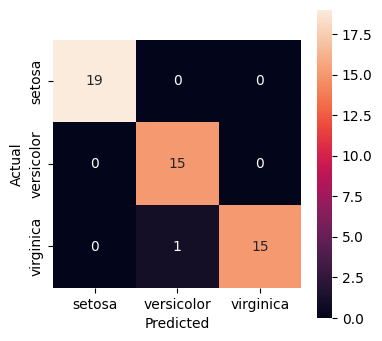

In [70]:
fix, ax = plt.subplots(1, 1, figsize=(4, 4))
cm = metrics.confusion_matrix(y_test, predictions)
ax = sns.heatmap(cm, annot=True, square=True, xticklabels=iris.target_names, yticklabels=iris.target_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

In [71]:
macro_precision = metrics.precision_score(y_test, predictions, average='macro')
print("Macro precision is:", macro_precision)

Macro precision is: 0.9791666666666666


In [72]:
macro_precision_1 = (np.diag(cm)/cm.sum(axis=0)).sum() / len(iris.target_names)
print(macro_precision_1)

0.9791666666666666


In [73]:
micro_precision = metrics.precision_score(y_test, predictions, average='micro')
print("Micro precision is:", micro_precision)

Micro precision is: 0.98


In [74]:
report = metrics.classification_report(y_test, predictions, target_names=iris.target_names)
print(report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



# Harmonijska sredina

$$
\begin{aligned}
F_1 = 2 \cdot \frac{1}{\frac{1}{precision} + \frac{1}{recall}}
\end{aligned}
$$

In [75]:
# ROC Receiver operating curve